In [ ]:
import warnings
import plotly.express as px

import matplotlib.pyplot as plt
import seaborn as sns
import cufflinks as cf
import plotly.graph_objs as go
%matplotlib inline
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
from wordcloud import WordCloud, ImageColorGenerator

In [ ]:
import numpy as np
import pandas as pd
import os

In [ ]:
food_df = pd.read_csv('/content/indian_food.csv')

Null values

In [ ]:
food_df[food_df.isnull().any(axis=1)]

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
110,Panjeeri,"Whole wheat flour, musk melon seeds, poppy see...",vegetarian,10,25,sweet,dessert,Uttar Pradesh,NaN


In [ ]:
food_df['region'] = food_df['region'].fillna('North')

In [ ]:
food_df[food_df.isnull().any(axis=1)]

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region


flavour_profile changing

In [ ]:
result = food_df[food_df['flavor_profile'] == '-1']
result

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
78,Chapati,"Whole wheat flour, olive oil, hot water, all p...",vegetarian,10,10,-1,main course,Maharashtra,West
104,Naan,"Whole wheat flour, honey, butter, garlic",vegetarian,60,30,-1,main course,Punjab,North
116,Rongi,"Garam masala powder, tomato, kasuri methi, cin...",vegetarian,10,30,-1,main course,Punjab,North
131,Kanji,"Carrot, yellow mustard, red chilli, black salt",vegetarian,10,45,-1,snack,Kerala,South
145,Pachadi,"Coconut oil, cucumber, curd, curry leaves, mus...",vegetarian,10,25,-1,main course,-1,South
146,Paniyaram,"Yogurt, ginger, curry leaves, baking soda, gre...",vegetarian,10,20,-1,main course,Tamil Nadu,South
150,Paruppu sadam,"Arhar dal, sambar powder, tomato, curry leaves...",vegetarian,10,20,-1,main course,Tamil Nadu,South
153,Puli sadam,"Urad dal, lemon, tamarind, cooked rice, curry ...",vegetarian,10,20,-1,main course,Tamil Nadu,South
155,Puttu,"Brown rice flour, sugar, grated coconut",vegetarian,495,40,-1,main course,Kerala,South
157,Sandige,"Thin rice flakes, black sesame seeds, curry le...",vegetarian,120,60,-1,main course,Karnataka,South


In [ ]:
food_df.loc[((food_df['ingredients'].str.contains('sugar')) | (food_df['ingredients'].str.contains('Condensed milk'))) & (food_df['flavor_profile'] == '-1'), 'flavor_profile'] = 'sweet'


In [ ]:
result_2 = food_df[food_df['flavor_profile'] == '-1']
result_2

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
78,Chapati,"Whole wheat flour, olive oil, hot water, all p...",vegetarian,10,10,-1,main course,Maharashtra,West
104,Naan,"Whole wheat flour, honey, butter, garlic",vegetarian,60,30,-1,main course,Punjab,North
116,Rongi,"Garam masala powder, tomato, kasuri methi, cin...",vegetarian,10,30,-1,main course,Punjab,North
131,Kanji,"Carrot, yellow mustard, red chilli, black salt",vegetarian,10,45,-1,snack,Kerala,South
145,Pachadi,"Coconut oil, cucumber, curd, curry leaves, mus...",vegetarian,10,25,-1,main course,-1,South
146,Paniyaram,"Yogurt, ginger, curry leaves, baking soda, gre...",vegetarian,10,20,-1,main course,Tamil Nadu,South
150,Paruppu sadam,"Arhar dal, sambar powder, tomato, curry leaves...",vegetarian,10,20,-1,main course,Tamil Nadu,South
153,Puli sadam,"Urad dal, lemon, tamarind, cooked rice, curry ...",vegetarian,10,20,-1,main course,Tamil Nadu,South
157,Sandige,"Thin rice flakes, black sesame seeds, curry le...",vegetarian,120,60,-1,main course,Karnataka,South
158,Sevai,"Sevai, parboiled rice, steamer",vegetarian,120,30,-1,main course,-1,South


Bitterfood
check


In [ ]:
b = food_df[food_df['flavor_profile'] == 'bitter']
b

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
71,Aloo methi,"Potato, fenugreek leaves, chillies, salt, oil",vegetarian,10,40,bitter,main course,Punjab,North
93,Karela bharta,"Bitter gourd, fennel, garam masala powder, chi...",vegetarian,20,50,bitter,main course,Punjab,North
196,Methi na Gota,"Rava, gram flour, lemon juice, turmeric, fenug...",vegetarian,15,30,bitter,main course,Gujarat,West
198,Muthiya,"Bottle gourd, whole wheat flour, rava, sesame ...",vegetarian,15,30,bitter,snack,Gujarat,West


In [ ]:
b_1 = food_df[food_df['ingredients'].str.contains('fenugreek leaves')]
b_1

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
71,Aloo methi,"Potato, fenugreek leaves, chillies, salt, oil",vegetarian,10,40,bitter,main course,Punjab,North
196,Methi na Gota,"Rava, gram flour, lemon juice, turmeric, fenug...",vegetarian,15,30,bitter,main course,Gujarat,West


changing remaining to spicy

In [ ]:
food_df['flavor_profile'].replace('-1','spicy',inplace = True)

<ipython-input-12-8b5dbcea934c>:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
result_3 = food_df[food_df['flavor_profile'] == '-1']
result_3

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region


check course

In [ ]:
result_4 = food_df[food_df['course'] == -1]
result_4

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region


prep_time and cook_time check

In [ ]:
result_5 = food_df[food_df['prep_time'] == -1]
result_5

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
19,Sohan papdi,"Gram flour, ghee, sugar, milk, cardamom",vegetarian,-1,60,sweet,dessert,Maharashtra,West
21,Chhena kheeri,"Chhena, sugar, milk",vegetarian,-1,60,sweet,dessert,Odisha,East
65,Pork Bharta,"Boiled pork, onions, chillies, ginger and garlic",non vegetarian,-1,-1,spicy,main course,Tripura,North East
132,Kaara kozhambu,"Sesame oil, drumstick, tamarind paste, sambar ...",vegetarian,-1,-1,spicy,main course,Tamil Nadu,South
134,Keerai masiyal,"Urad dal, curry leaves, sugar, mustard seeds, ...",vegetarian,-1,-1,spicy,main course,Tamil Nadu,South
148,Paravannam,"Raw rice, jaggery, milk",vegetarian,-1,-1,spicy,main course,Kerala,South
152,Poriyal,"Chana dal, urad dal, beans, coconut, mustard",vegetarian,-1,-1,spicy,main course,Tamil Nadu,South
167,Kolim Jawla,"Baingan, fish, coconut oil, fresh coconut, ginger",non vegetarian,-1,-1,spicy,main course,Maharashtra,West
172,Bombil fry,"Bombay duck, malvani masala, rice flour, bomba...",non vegetarian,-1,-1,spicy,main course,Maharashtra,West
185,Ghooghra,"Dry fruits, semolina, all purpose flour",vegetarian,-1,-1,spicy,snack,Gujarat,West


In [ ]:
food_df.loc[(food_df['diet'] == 'vegetarian') & (food_df['flavor_profile'] == 'sweet') & (food_df['prep_time'] == -1), 'prep_time'] = 35

In [ ]:
food_df.loc[(food_df['diet'] == 'vegetarian') & (food_df['flavor_profile'] == 'spicy') & (food_df['prep_time'] == -1), 'prep_time'] = 30

In [ ]:
food_df.loc[(food_df['diet'] == 'non vegetarian') & (food_df['flavor_profile'] == 'spicy') & (food_df['prep_time'] == -1), 'prep_time'] = 45

In [ ]:
result_6 = food_df[food_df['cook_time'] == -1]
result_6

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
65,Pork Bharta,"Boiled pork, onions, chillies, ginger and garlic",non vegetarian,45,-1,spicy,main course,Tripura,North East
132,Kaara kozhambu,"Sesame oil, drumstick, tamarind paste, sambar ...",vegetarian,30,-1,spicy,main course,Tamil Nadu,South
134,Keerai masiyal,"Urad dal, curry leaves, sugar, mustard seeds, ...",vegetarian,30,-1,spicy,main course,Tamil Nadu,South
148,Paravannam,"Raw rice, jaggery, milk",vegetarian,30,-1,spicy,main course,Kerala,South
152,Poriyal,"Chana dal, urad dal, beans, coconut, mustard",vegetarian,30,-1,spicy,main course,Tamil Nadu,South
167,Kolim Jawla,"Baingan, fish, coconut oil, fresh coconut, ginger",non vegetarian,45,-1,spicy,main course,Maharashtra,West
172,Bombil fry,"Bombay duck, malvani masala, rice flour, bomba...",non vegetarian,45,-1,spicy,main course,Maharashtra,West
185,Ghooghra,"Dry fruits, semolina, all purpose flour",vegetarian,30,-1,spicy,snack,Gujarat,West
187,Halvasan,"Whole wheat rava, chia seed, lemon, edible gum...",vegetarian,35,-1,sweet,dessert,Gujarat,West
213,Mag Dhokli,"Moong beans, jaggery, red chillies, oil, salt",vegetarian,30,-1,spicy,snack,Gujarat,West


In [ ]:
food_df.loc[(food_df['diet'] == 'vegetarian') & (food_df['flavor_profile'] == 'sweet') & (food_df['cook_time'] == -1), 'cook_time'] = 15

In [ ]:
food_df.loc[(food_df['diet'] == 'vegetarian') & (food_df['flavor_profile'] == 'spicy') & (food_df['cook_time'] == -1), 'cook_time'] = 40
food_df.loc[(food_df['diet'] == 'non vegetarian') & (food_df['flavor_profile'] == 'spicy') & (food_df['cook_time'] == -1), 'cook_time'] = 60

In [ ]:
result_6 = food_df[food_df['cook_time'] == -1]
result_6

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region


change state and region

In [ ]:
food_df.loc[food_df['state']=='-1','state']='Others'
food_df.loc[food_df['region']=='-1','region']='Others'

check if any remaining


In [ ]:
rows_containing_1 = food_df[food_df.isin([-1]).any(axis=1)]
rows_containing_1

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region


Create new col total time

In [ ]:
food_df['total_time']=food_df.cook_time+food_df.prep_time
food_df.head()

,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region,total_time
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East,70
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West,110
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North,75
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West,45
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East,55


In [ ]:
y=food_df['diet'].value_counts()
y

,count
diet,
vegetarian,226
non vegetarian,29


Getting the diet rate of India


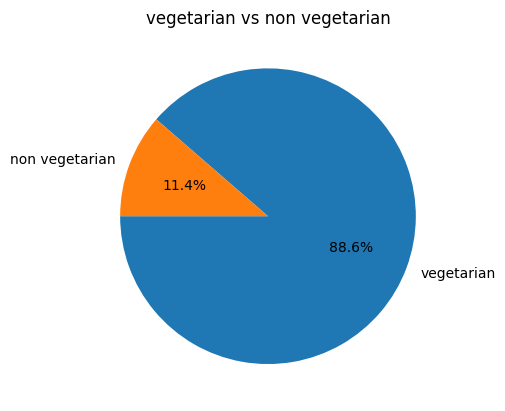

In [ ]:
#plotting pie chart of vegetarian dishes vs non vegetarin dishes
plt.pie(y.values, labels=y.index, autopct='%1.1f%%', startangle=180)
plt.title('vegetarian vs non vegetarian')
plt.show()

Distribution of Diet by Region

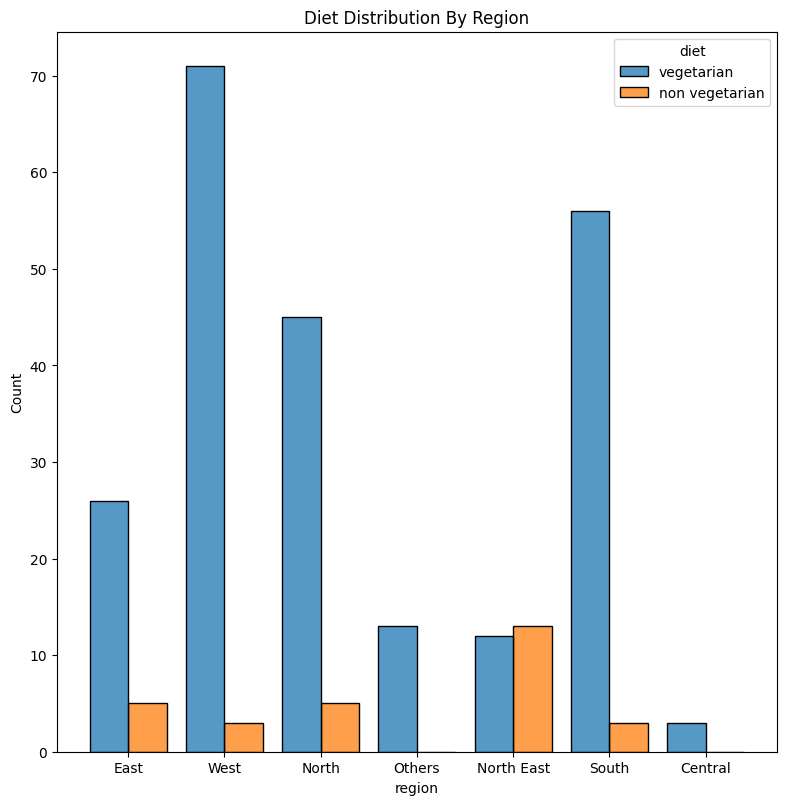

In [ ]:
figure = plt.figure(figsize=(8,8))

ax = figure.add_axes([0,0,0.9,0.9])

sns.histplot(food_df, x='region', hue = 'diet', shrink=0.8, multiple='dodge',ax=ax)
ax.set_title('Diet Distribution By Region');

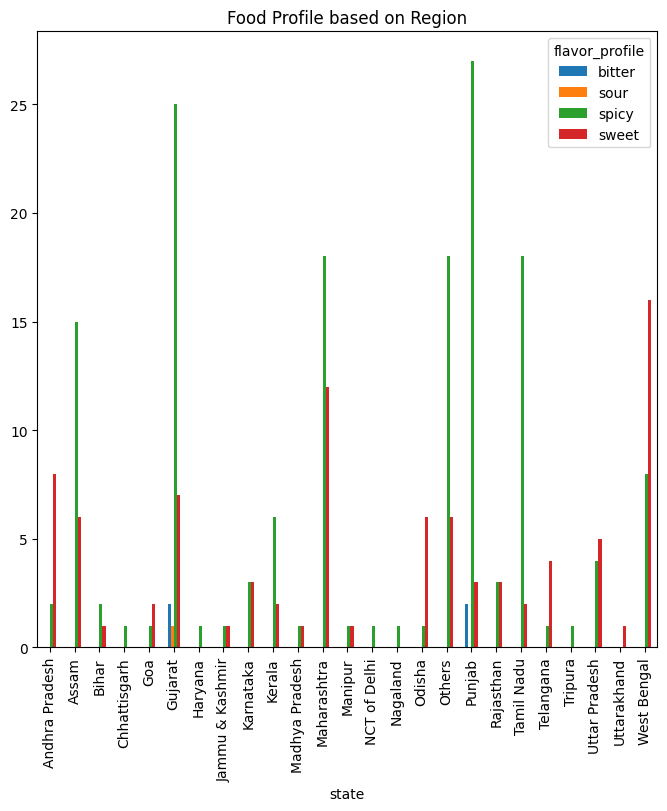

In [ ]:
pd.crosstab(food_df["state"],food_df["flavor_profile"]).plot(kind="bar",figsize=(8,8))
plt.title("Food Profile based on Region")
plt.show()

Flavour_Profile


In [ ]:
px.pie(food_df, names='flavor_profile', title='Flavour Profile')


Food prep and cooking analysis

How much time will the dishes take to complete.

In [ ]:
food_df['total_time'] = (food_df['prep_time'] +food_df['cook_time'])/60

In [ ]:
cmap = plt.get_cmap('rainbow')

# Create a list of colors for each category
n_colors = len(food_df['state'].unique())
colors = [cmap(i / n_colors) for i in range(n_colors)]

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:2761: UserWarning:

catplot is a figure-level function and does not accept target axes. You may wish to try stripplot

<ipython-input-36-f88505ec62fc>:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




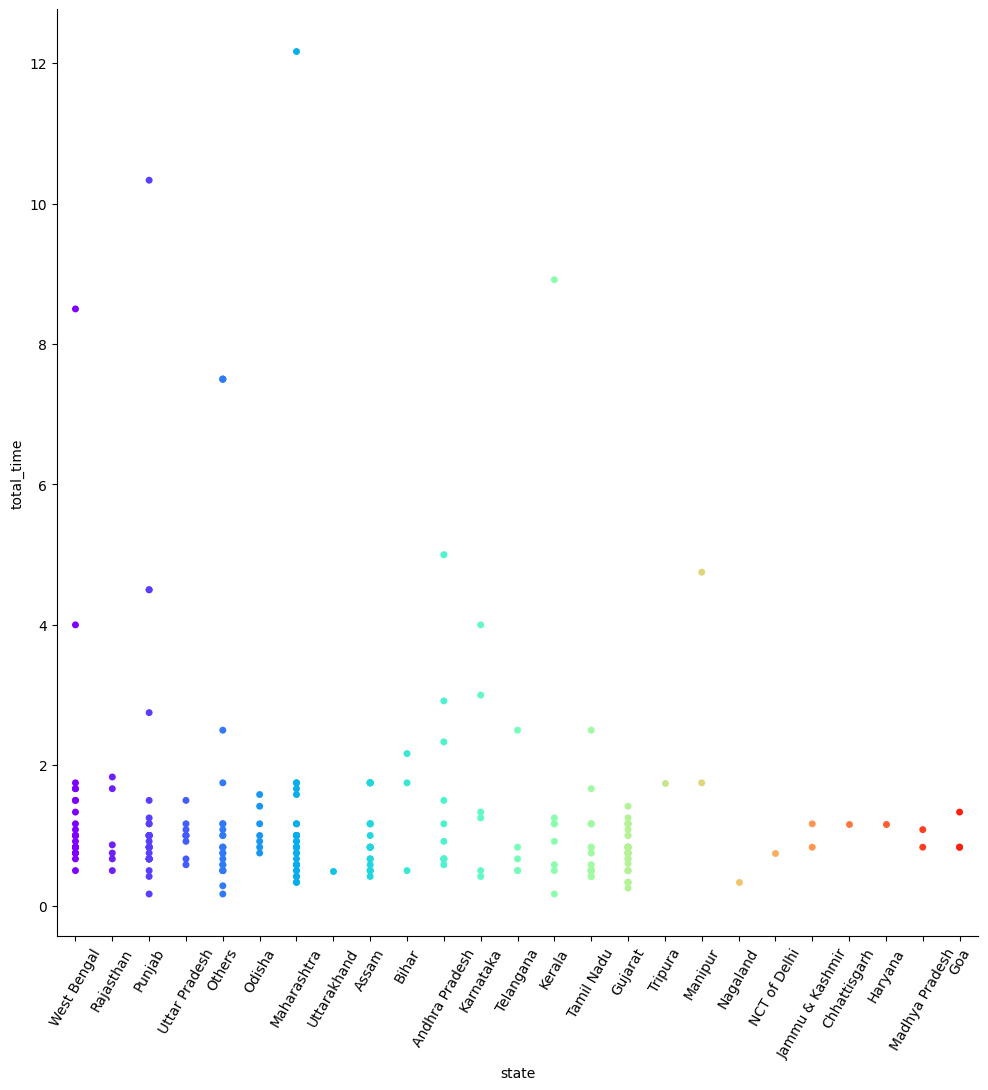

In [ ]:
cat = sns.catplot(x='state', y='total_time', data=food_df,ax=ax,height=10, jitter=False, palette=colors)
plt.xticks(rotation=60);

Time taking dishes


In [ ]:
s = food_df[['name', 'total_time']].set_index('name')
s
q=s.sort_values(by=['total_time'],ascending=False)
o=q[0:10]
o

,total_time
name,
Shrikhand,12.166667
Pindi chana,10.333333
Puttu,8.916667
Misti doi,8.500000
Masala Dosa,7.500000
Idli,7.500000
Dosa,7.500000
Poornalu,5.000000
Chak Hao Kheer,4.750000


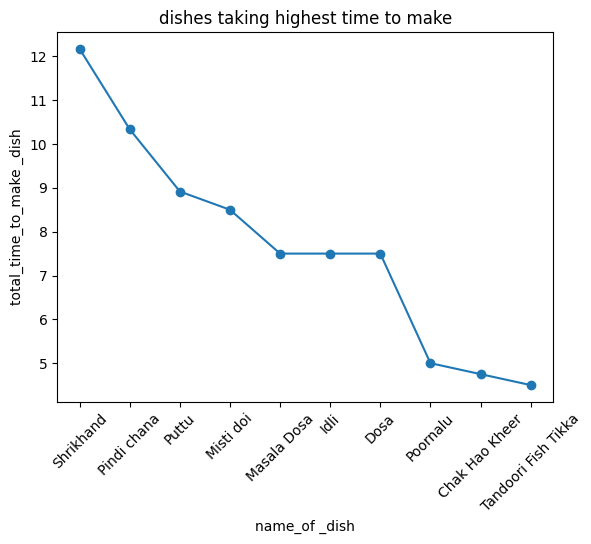

In [ ]:
plt.plot(o.index,o.values,marker='o')
plt.xlabel('name_of _dish')
plt.ylabel('total_time_to_make _dish')
plt.title('dishes taking highest time to make')
plt.xticks(rotation=45)
plt.show()

Different diet per region

In [ ]:
px.bar(
    food_df, x='region', color= 'diet',
       title= 'Different Diet per Region',
       labels= {'region': 'Region', 'diet': 'Diet'},
       color_discrete_sequence=[ '#D8BFD8', '#FFFF00']
      )

Comparison of Food Course Distribution Across States and Regions in India

This heading suggests a comparative analysis of food course distribution, focusing on differences and similarities across states and regions.

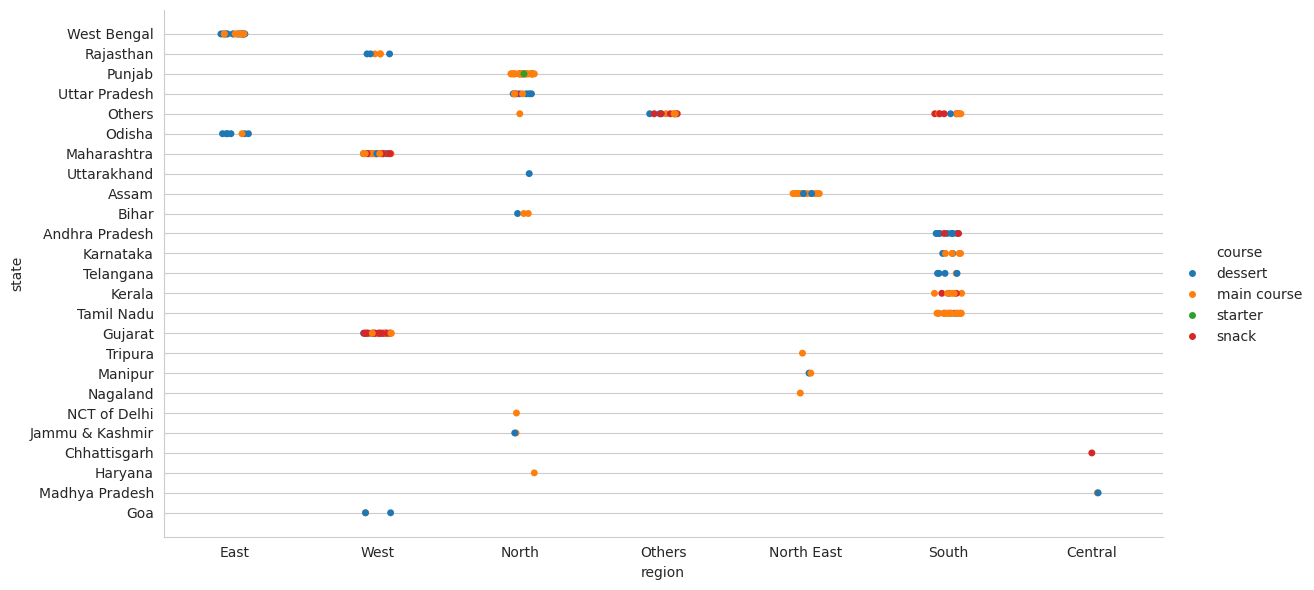

In [ ]:
sns.set_style("whitegrid")
sns.catplot(data=food_df, x="region", y="state", hue="course", height=6, aspect=2)


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning:

8.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning:

35.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning:

6.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



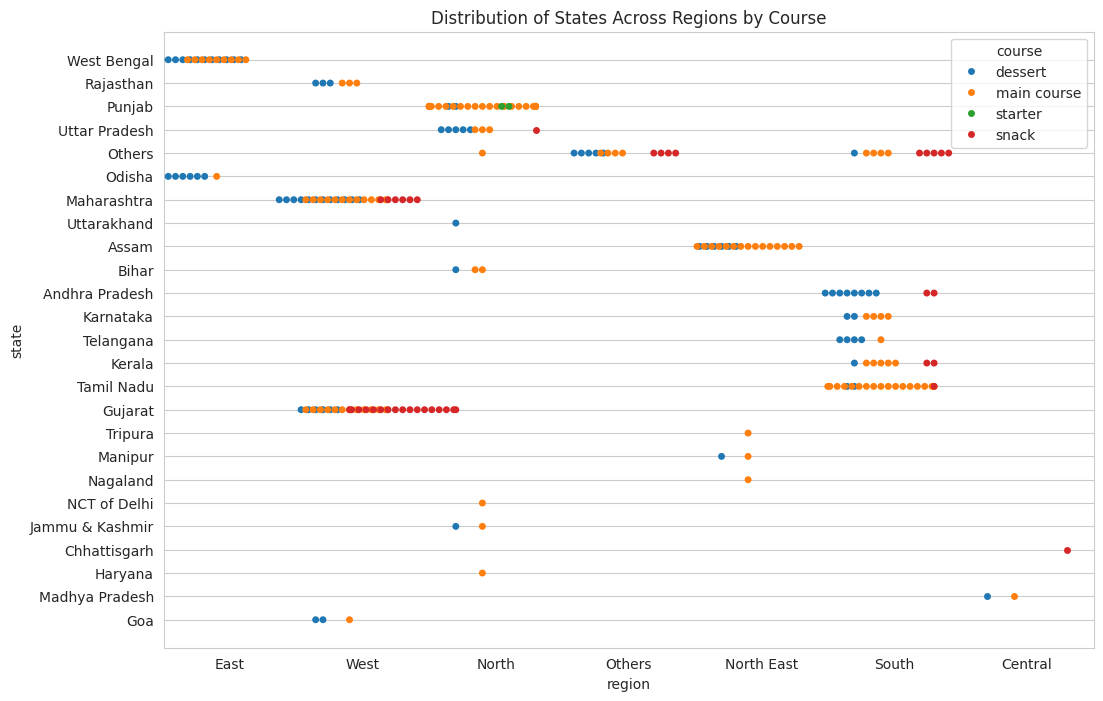

In [ ]:
sns.set_style("whitegrid")

# Create the swarm plot
plt.figure(figsize=(12, 8))
sns.swarmplot(data=food_df, x="region", y="state", hue="course", dodge=True)

# Add a title
plt.title('Distribution of States Across Regions by Course')

# Show the plot
plt.show()

Geographical representation of state-wise distribution of spicy dishes in India

In [ ]:
states = list(food_df['state'].value_counts().keys())
counts = list(food_df['state'].value_counts().values)

In [ ]:
states_spicy = list(food_df[food_df['flavor_profile'] == 'spicy']['state'].value_counts().keys())
counts_spicy = list(food_df[food_df['flavor_profile'] == 'spicy']['state'].value_counts().values)

In [ ]:
data = dict(type = 'choropleth',
            geojson="https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson",
            featureidkey = 'properties.ST_NM',
            locationmode='geojson-id',
            locations=states_spicy,
            z = counts_spicy,

            autocolorscale = False,
            colorscale= 'reds',
            marker_line_color = 'rgb(255,255,255)',

            colorbar = dict (
                title={'text': "Spicy Dish Counts"},
                thickness=15,
                len=0.35,
                bgcolor='rgba(255,255,255,0.6)',

                tick0=0,
                dtick=20000,

                xanchor='left',
                x=0.01,
                yanchor='bottom',
                y=0.05
            )
           )

In [ ]:
layout = dict(
            title=dict(
                text='Spicy Dishes Distribution By State',
                xanchor='center',
                x=0.5,
                yref='paper',
                yanchor='bottom',
                y=1,
                pad={'b':10}
            ),

            geo= {
                'visible': False,
                'projection': dict(
                    type = 'conic conformal',
                    parallels=[12.472944444, 35.172805555556],
                    rotation = {'lat':24,'lon':80},
                ),
                'lonaxis': {'range':[68,98]},
                'lataxis': {'range':[6,38]}
            },

            margin={'r':0,'t':30,'l':0, 'b':0},
            height=550,
            width=550
)

In [ ]:
choromap = go.Figure(data=[data], layout=layout)
iplot(choromap,show_link = False)

Lets take a look at ingredients involved

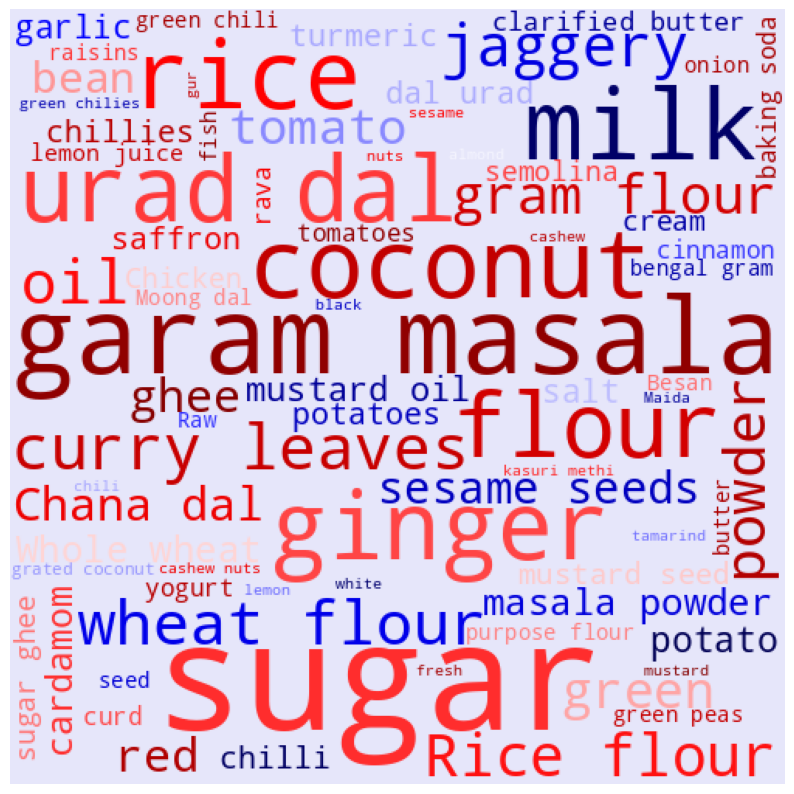

In [ ]:
dessert_df  = food_df['ingredients'].reset_index()

ingredients = []
for i in range(0,len(dessert_df)):
    text = dessert_df['ingredients'][i].split(',')
    text = ','.join(text)
    ingredients.append(text)
    text = ' '.join(ingredients)

wordcloud = WordCloud(width = 500, height = 500, colormap = 'seismic'
                      ,background_color ='lavender',
                min_font_size = 10).generate(text)
plt.figure(figsize = (10, 14), facecolor = None)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()